## Training Notebook Requirement

The training notebook must save `model_config.json` after training completes.

**Add this function to your training notebook (secbert_smaller_teacher.ipynb) after training:**

```python


# Call after training:
# 
```

## Random Seed

In [1]:
import random
import torch
import numpy as np
import json


In [2]:
# Import reusable functions and classes from shared_utils
from shared_utils import (
    set_seed,
    convert_span_to_number,
    process_batch,
    process_batch_wrapper,
    process_data,
    count_lines,
    load_counter,
    MultiTaskIterableDataset,
    BufferedShuffleDataset,
    ProcessedIterableDataset,
    MultiTaskModel,
    GateHead,
    FocalLoss,
    CB_CE_Loss,
    hits_at_k,
    compute_loss,
    load_model_config,
    save_model_config,
    evaluate_model,
    evaluate_classification,
    evaluate_regression,
    evaluate_model_with_gate_filter,
    evaluate_model_all_gate
)

/home/mo1om/code/miniconda/envs/XBRL/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print(torch.__version__)

2.9.0+cu130


## Dataset

In [4]:
from transformers import AutoTokenizer
import torch

# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# tokenizer = AutoTokenizer.from_pretrained("yiyanghkust/finbert-pretrain", local_files_only=True)
tokenizer = AutoTokenizer.from_pretrained("nlpaueb/sec-bert-base")

# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", local_files_only=True)

# 設定預設值
CLASSIFICATION_MISSING_VALUE = -100
NUMERIC_MISSING_VALUE = torch.finfo(torch.float32).max  # 3.4028235e+38

#### IterableDataset

#### Load Processed Iterable Dataset

In [5]:

train_files = ["processed_iterable_dataset/train_400k.jsonl"]
valid_files = ["processed_iterable_dataset/valid_50k.jsonl"] 
test_files = ["processed_iterable_dataset/test_50k.jsonl"]

In [6]:
# Read pre-processed JSONL files
from torch.utils.data import DataLoader
from shared_utils import ProcessedIterableDataset


In [7]:
train_dataset = ProcessedIterableDataset(train_files)

valid_dataset = ProcessedIterableDataset(valid_files)

test_dataset = ProcessedIterableDataset(test_files)

batch_size = 256
num_workers=10
# train_loader = DataLoader(train_dataset, batch_size = batch_size, num_workers = 4, drop_last = False)
# valid_loader = DataLoader(valid_dataset, batch_size = batch_size, num_workers = 4, drop_last = False)
# test_loader = DataLoader(test_dataset, batch_size = batch_size, num_workers = 4, drop_last = False)

train_loader = DataLoader(train_dataset, batch_size = batch_size, num_workers = num_workers)
valid_loader = DataLoader(valid_dataset, batch_size = batch_size, num_workers = num_workers)
test_loader = DataLoader(test_dataset, batch_size = batch_size, num_workers = num_workers)

In [8]:
import os
from shared_utils import count_lines

# Calculate approximate batch counts
train_total_samples = sum(count_lines(f) for f in train_files)
train_approx_batches = train_total_samples // batch_size

valid_total_samples = sum(count_lines(f) for f in valid_files)
valid_approx_batches = valid_total_samples // batch_size

test_total_samples = sum(count_lines(f) for f in test_files)
test_approx_batches = test_total_samples // batch_size


print(f"Train 預計數量: {train_total_samples}, 預計 {train_approx_batches} 個 batch")
print(f"Valid 預計數量: {valid_total_samples}, 預計 {valid_approx_batches} 個 batch")
print(f"Test 預計數量: {test_total_samples}, 預計 {test_approx_batches} 個 batch")


Train 預計數量: 728821, 預計 2846 個 batch
Valid 預計數量: 91168, 預計 356 個 batch
Test 預計數量: 90337, 預計 352 個 batch


## Count

#### 計算 tag, scale, negative, time 的類別個數
計算後存成 JSON，之後可以直接用

In [9]:
# IterableDataset

with open('../processed_data_task1_smaller/counter/tag_count_train_400k.json', 'r', encoding = 'utf-8') as file:
# with open('processed_iterable_dataset/counter/train_8k.json', 'r', encoding = 'utf-8') as file:
# with open('../processed_data_task1/counter/tag_count_train_data.json', 'r', encoding = 'utf-8') as file:    
    tag_counter = json.load(file)
    
# 想讓數量多的類別在前面

tag_counter = dict(sorted(tag_counter.items(), key = lambda item:item[1], reverse=True))
print(len(tag_counter))
count_threshold = 10
standard_rare_tags = {tag for tag, count in tag_counter.items() if count < count_threshold}
tag_list = [tag for tag in tag_counter.keys() if tag not in standard_rare_tags]
print(tag_list[:5])
print(f'Length of standard_rare_tags: {len(standard_rare_tags)}')
print(f'Length of all tags: {len(tag_list)}')

id2tag = {idx: tag for idx, tag in enumerate(tag_list)}
tag2id = {tag: idx for idx, tag in enumerate(tag_list)}

time_list = ['instant; past', 'instant; current', 'instant; future', 'period; past', 'period; current', 'period; future', 'period; past_current', 'period; current_future', 'period; past_future']
id2time = {idx: time for idx, time in enumerate(time_list)}
time2id = {time: idx for idx, time in enumerate(time_list)}

scale_list = [str(i) for i in range(-12, 13)]
id2scale = {idx: scale for idx, scale in enumerate(scale_list)}
scale2id = {scale: idx for idx, scale in enumerate(scale_list)}
# with open('processed_data_task1_smaller/counter/train_100k.json')

978
['custom', 'standard_rare', 'us-gaap:DebtInstrumentInterestRateStatedPercentage', 'us-gaap:DebtInstrumentBasisSpreadOnVariableRate1', 'us-gaap:DebtInstrumentFaceAmount']
Length of standard_rare_tags: 0
Length of all tags: 978


In [10]:
# load counter result

def load_counter(target_attr):
    target_path = f'processed_iterable_dataset/counter/secbert_train_small_{target_attr}.json'

    with open(target_path, "r", encoding='utf-8') as f:
        data = json.load(f)
    return data

train_tag_counts = load_counter("tag")
train_tag_counts.pop('-100', None)
num_tag_samples = [train_tag_counts.get(str(tag2id[tag]), 0) for tag in tag_list]
print(f'Total tag class: {len(train_tag_counts)}')
train_time_counts = load_counter("time")
train_time_counts.pop('-100', None)
num_time_samples = [train_time_counts.get(str(time2id[time]), 0) for time in time_list]
print(train_time_counts)

train_neg_counts = load_counter("negative")
train_neg_counts.pop('-100', None)
num_neg_samples = [train_neg_counts.get(neg, 0) for neg in sorted(train_neg_counts.keys())]
print(train_neg_counts)

train_scale_counts = load_counter("scale")
train_scale_counts.pop('-100', None)
num_scale_samples = [train_scale_counts.get(str(scale2id[scale]), 0) for scale in scale_list]
print(train_scale_counts)

Total tag class: 978
{'6': 70691, '4': 124746, '3': 175155, '1': 195615, '0': 135307, '2': 14182, '5': 10629, '7': 351, '8': 490}
{'0': 701747, '1': 19527}
{'18': 328811, '10': 117673, '12': 152722, '15': 50895, '21': 18758, '8': 1695, '17': 38, '14': 13, '9': 20, '11': 18, '13': 17, '24': 30, '16': 37, '20': 2, '6': 5, '19': 3}


## Model

# SecBERT Multi-Task Model — Inference & Evaluation

**Refactored Testing Notebook** (v2.0)

This notebook loads a trained multi-task model and evaluates it on test data.

## Key Changes:
✅ Loads `model_config.json` instead of recomputing ID mappings from raw data
✅ Eliminates the critical ID shift bug between training and testing
✅ Strict CPU/CUDA device handling
✅ Dynamic checkpoint configuration (easy switching)
✅ Identical model definitions to training notebook

## Prerequisites:
1. Training notebook must save `model_config.json` (see section below)
2. Model checkpoint must exist at `model_weight/{MODEL_NAME}/{RUN_DATE}_{RUN_INDEX}_step{CHECKPOINT_STEP}.pt`
3. Test data must be available at the configured path

## Loss

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
# device = 'cpu'

cuda


In [12]:
# time loss
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np
from torch import nn

# 取得 time 類別的出現次數
time_class_counts = torch.tensor(num_time_samples)

total_samples = sum(train_time_counts.values())
num_classes = len(train_time_counts)

time_class_weights = {
    cls: total_samples / (num_classes * count) 
    for cls, count in train_time_counts.items()
}
time_class_weights = dict(sorted(time_class_weights.items(), key = lambda item:item[0]))
time_class_weights = list(time_class_weights.values())

time_smoothed_weights = np.log1p(time_class_weights)

MIN_WEIGHT =  1 # 設定最小值
time_smoothed_weights = np.clip(time_smoothed_weights, MIN_WEIGHT, None)
time_smoothed_weights[0] = 1.5
time_smoothed_weights[6] = 1.5
print(time_smoothed_weights)
time_class_weights = torch.tensor(time_smoothed_weights, dtype=torch.float).to(device)
time_loss_fn = nn.CrossEntropyLoss(weight = time_class_weights, ignore_index = CLASSIFICATION_MISSING_VALUE)

[1.5        1.         1.90167407 1.         1.         2.15193528
 1.5        5.44323412 5.11132642]


In [13]:
# scale loss
scale_class_weights = {
    15: 1.2,  21: 1.5
}
num_classes = len(scale_list)
weights_list = [scale_class_weights.get(i, 1.0) for i in range(num_classes)]

scale_class_weights = torch.tensor(weights_list, dtype=torch.float).to(device)

# 定義 loss function
scale_loss_fn = nn.CrossEntropyLoss(weight=scale_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE)

In [14]:
from torch import nn
# --- Tag Loss ---
# (Assumes you have num_tag_samples defined as before)
tag_loss_fn = CB_CE_Loss(num_tag_samples, beta=0.99, ignore_index=CLASSIFICATION_MISSING_VALUE)

# --- Time Loss ---
# (Assumes you have time_class_weights defined as before)
# Note: standard CrossEntropyLoss supports reduction='none' by default
time_loss_fn = nn.CrossEntropyLoss(weight=time_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE, reduction='none')

# --- Scale Loss ---
# (Assumes scale_class_weights defined)
scale_loss_fn = nn.CrossEntropyLoss(weight=scale_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE, reduction='none')

# --- Negative Loss ---
neg_loss = FocalLoss(alpha=0.25, gamma=3.0, reduction="none")

In [15]:
# # train_time_counts = get_value_counts(train_loader, "time")
# # num_time_samples = [train_time_counts.get(time, 0) for time in sorted(train_time_counts.keys())]
# time_loss_fn = CB_CE_Loss(num_time_samples)

In [16]:
from torch import nn
CLASSIFICATION_MISSING_VALUE=-100
classification_loss = nn.CrossEntropyLoss(ignore_index = CLASSIFICATION_MISSING_VALUE)
mse_loss = nn.MSELoss()


In [17]:
# def compute_loss(outputs, targets, values, task_weights = None, hits_k = False):
#     losses = {}
#     tag_hits_k = {}
#     if "tag" in targets:
#         losses["tag"] = tag_loss_fn(outputs["tag"], targets["tag"])

#         if hits_k:
#             tag_hits_k["hits_1"] = hits_at_k(outputs["tag"], targets["tag"], k = 1)
#             tag_hits_k["hits_3"] = hits_at_k(outputs["tag"], targets["tag"], k = 3)
#             tag_hits_k["hits_5"] = hits_at_k(outputs["tag"], targets["tag"], k = 5)

#     if "time" in targets:
#         losses["time"] = time_loss_fn(outputs["time"], targets["time"])
    
#     if "scale" in targets:
#         losses["scale"] = scale_loss_fn(outputs["scale"], targets["scale"])
    

#     if "negative" in targets:
#         losses["negative"] = neg_loss(outputs["negative"], targets["negative"])
    
#     # gate: [batch_size, 1] -> [batch_size]
#     gate = outputs["gate"].squeeze(-1)
    
#     # Compute weighted sum of task losses: sum over tasks
#     # Each task loss is a scalar (already reduced by their respective loss functions)
#     total_raw_loss = sum(task_weights[k] * losses[k] for k in losses.keys())
    
#     # Apply gate weighting and regularization
#     # (1 - gate) * total_loss +  gate^2
#     weighted_loss = (1 - gate) * total_raw_loss + gate.pow(2)
    

#     # Normalize by task weights sum
#     total_loss = weighted_loss / sum(task_weights.values())
#     return (total_loss, losses, tag_hits_k) if hits_k else (total_loss, losses)   

# 恢復訓練

In [18]:
import wandb
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F
from transformers import get_scheduler
from tqdm import tqdm
import os

num_warmup_steps = 5
num_epochs = 30
eval_step = 20000 # 150222 個 batch
# checkpoint_save_step = 50
task_weights = {"tag": 10.0, "time": 0.3, "scale": 0.2, "negative": 10.0}  
# task_weights = get_task_weights(0)
patience = 5
max_saved_models = 2
saved_models = [] 

model_name = "secbert"
date = "0426"
index = 173
run_name = f"{model_name}-{date}-{index}"

model = MultiTaskModel(
    "nlpaueb/sec-bert-base",
    num_tags = len(tag_list), 
    num_times = len(time_list),
    num_scales= len(scale_list)
)


bert_lr = 1e-5
tag_head_lr = 5e-4
time_head_lr = 1e-5
scale_head_lr = 3e-5
negative_head_lr = 2e-5

optimizer = AdamW([
    {"params": model.bert.parameters(), "lr": bert_lr, "weight_decay": 1e-2},  
    {"params": model.tag_head.parameters(), "lr": tag_head_lr,  "weight_decay": 1e-2},  
    {"params": model.time_head.parameters(), "lr": time_head_lr,  "weight_decay": 1e-2},  
    {"params": model.scale_head.parameters(), "lr": scale_head_lr,  "weight_decay": 1e-2},
    {"params": model.negative_head.parameters(), "lr": negative_head_lr,  "weight_decay": 1e-2},  
])

# num_total_steps= num_epochs * train_approx_batches
# scheduler = CosineAnnealingLR(optimizer, T_max = num_total_steps // 4, eta_min = 1e-7)

device = "cuda" if torch.cuda.is_available() else "cpu"
# device = 'cpu'
print(device)
best_val_loss = float("inf")
early_stop_counter = 0 


os.makedirs(f'model_weight/{model_name}', exist_ok=True)
os.makedirs(f'check_point/{model_name}', exist_ok=True)


# import wandb

# # generate a new run name or ID if needed
# run_name = f"{model_name}-{date}-{index}-gate_mechanism"

# wandb.init(
#     project="multi-task-model",
#     name=run_name,
#     # Remove 'id' and 'resume' if this is a fresh start for the new model logic
#     # id='new_id_here', 
#     # resume="allow", 
#     config={
#         "epochs": num_epochs,
#         "batch_size": batch_size,
#         "learning_rates": { 
#             "bert": bert_lr,
#             "tag_head": tag_head_lr,
#             "time_head": time_head_lr,
#             "scale_head": scale_head_lr,
#             "negative_head": negative_head_lr,
#             "gate_head": bert_lr # or whatever custom LR you used for gate
#         },
#         "task_weights": task_weights,
#         "train_data_size": train_total_samples,
#         "model_architecture": "SecBERT + GateHead + HybridLoss"
#     }
# )

# # Optional: Watch the model to see gradients (specifically helpful to see if GateHead is dying)
# wandb.watch(model, log="gradients", log_freq=100)
# # wandb.watch(model, log="all")

 

cuda


In [19]:
# # ---------------------------------------------------------
# # ONLY RUN THIS CELL AFTER YOUR MODEL IS DEFINED AND TRAINED
# # ---------------------------------------------------------
# model_name="secbert"
# # Ensure output directory exists (based on your script variables)
# output_dir = os.path.join("model_weight", model_name) # e.g. model_weight/secbert

# save_model_config(
#     model=model,      # This variable must exist!
#     tag2id=tag2id,    # This variable must exist!
#     time2id=time2id,  # This variable must exist!
#     scale2id=scale2id, # This variable must exist!
#     output_dir=output_dir,
#     run_name=run_name # This variable must exist!
# )

# Test

In [20]:
# ========================================================================
# ===== IMPROVED EVALUATION FUNCTION (Compatible with Multi-Gate Model) =====
# ========================================================================

import numpy as np
import pandas as pd
from collections import defaultdict
import csv
from tqdm import tqdm
import os
import torch

# def evaluate_model(
#     model,
#     test_loader,
#     device,
#     task_weights,
#     error_file_path,
#     save_errors=False,
#     verbose=True
# ):
#     """
#     Evaluate the model on test data.
#     Modified to handle models returning a dictionary of multiple gates.
#     """
    
#     os.environ["WANDB_DISABLED"] = "true"
#     model.eval()
    
#     all_losses = {"tag": 0, "time": 0, "fact": 0, "scale": 0, "negative": 0}
#     total_hits = {"hits_1": 0, "hits_3": 0, "hits_5": 0}
#     predictions = defaultdict(list)
#     ground_truths = defaultdict(list)
#     errors = defaultdict(list)
    
#     test_batch_count = 0
#     fact_results = []
    
#     # Use tqdm if verbose
#     loader = tqdm(test_loader, desc="Evaluating") if verbose else test_loader
    
#     with torch.no_grad():
#         for batch_idx, batch in enumerate(loader):
#             # ===== Load batch to device =====
#             input_ids = batch["input_ids"].to(device)
#             attention_mask = batch["attention_mask"].to(device)
#             start_tokens = batch["start_token"].to(device)
#             end_tokens = batch["end_token"].to(device)
#             values = batch["value"].to(device)
            
#             targets = {
#                 "tag": batch["tag"].to(device),
#                 "time": batch["time"].to(device),
#                 "fact": batch["fact"].to(device),
#                 "scale": batch["scale"].to(device),
#                 "negative": batch["negative"].to(device)
#             }
            
#             # ===== Forward pass =====
#             outputs = model(input_ids, attention_mask, start_tokens, end_tokens)
            
#             # ===== Compute loss =====
#             # Note: Ensure your compute_loss can handle the 'gates' dict or ignores it safely
#             loss, losses, tag_hits_k = compute_loss(
#                 outputs, targets, values, task_weights, hits_k=True,tag_loss_fn=tag_loss_fn,
#                 time_loss_fn=time_loss_fn,
#                 scale_loss_fn=scale_loss_fn,
#                 neg_loss=neg_loss
#             )
            
#             # ===== Extract gate values for debugging (FIXED BLOCK) =====
#             # The model returns "gates" (dict of 4 tensors) but logic expects "gate" (1 tensor)
#             if "gate" in outputs:
#                 # Case 1: Model returns a single gate tensor
#                 gate_tensor = outputs["gate"]
#             elif "gates" in outputs and isinstance(outputs["gates"], dict):
#                 # Case 2: Model returns a dict of task-specific gates
#                 # Solution: Average the 4 gates to get a single "noise score" for logging
#                 gates_dict = outputs["gates"]
#                 # Sum all gate tensors (tag + time + scale + negative)
#                 sum_gates = sum(gates_dict.values()) 
#                 # Divide by number of tasks to get average
#                 gate_tensor = sum_gates / len(gates_dict)
#             else:
#                 # Case 3: Fallback (should not happen with correct model)
#                 gate_tensor = torch.zeros(input_ids.size(0), 1).to(device)

#             # Now we have a single tensor to convert to list
#             gate_values = gate_tensor.squeeze(-1).cpu().tolist()
#             predictions["gate"].extend(gate_values)
            
#             test_batch_count += 1
            
#             # ===== Aggregate metrics =====
#             if tag_hits_k:
#                 for key in total_hits:
#                     total_hits[key] += tag_hits_k[key]
            
#             for key in all_losses:
#                 if key in losses:
#                     val = losses[key]
#                     if isinstance(val, torch.Tensor):
#                         all_losses[key] += val.item()
#                     else:
#                         all_losses[key] += val
            
#             # ===== Classification predictions (tag, time, scale, negative) =====
#             for key in ["scale", "negative", "tag", "time"]:
#                 pred = torch.argmax(outputs[key], dim=-1).cpu().tolist()
#                 true = targets[key].cpu().tolist()
                
#                 for i, (p, t) in enumerate(zip(pred, true)):
#                     predictions[key].append(p)
#                     ground_truths[key].append(t)
                    
#                     if p != t:
#                         errors[key].append({
#                             "batch_idx": batch_idx,
#                             "sample_idx": i,
#                             "true": t,
#                             "pred": p,
#                             "gate": gate_values[i]
#                         })
            
#             # ===== Fact (Numeric) Predictions =====
#             if "fact" in targets:
#                 negative_pred = outputs["negative"].argmax(dim=-1).cpu().numpy()
                
#                 if "scale" in outputs:
#                     scale_pred_class = outputs["scale"].argmax(dim=-1).cpu().numpy()
#                 else:
#                     scale_pred_class = np.ones_like(
#                         values.cpu().numpy(), dtype=np.int64
#                     )
                
#                 # Convert scale IDs to actual scale values
#                 id2scale_np = np.array(
#                     [float(id2scale[idx]) for idx in range(len(id2scale))],
#                     dtype=np.float64
#                 )
#                 scale_pred_values = id2scale_np[scale_pred_class]
                
#                 values_np = values.cpu().numpy()
#                 fact_pred = (
#                     values_np * ((-1) ** negative_pred) * (10 ** scale_pred_values)
#                 )
#                 fact_target = targets["fact"].view(-1).cpu().numpy()
                
#                 for i, (p, t, neg, scale, scale_val, val) in enumerate(
#                     zip(
#                         fact_pred,
#                         fact_target,
#                         negative_pred,
#                         scale_pred_class,
#                         scale_pred_values,
#                         values_np,
#                     )
#                 ):
#                     # Skip missing values
#                     if t == NUMERIC_MISSING_VALUE or t > 1e30:
#                         continue
                    
#                     predictions["fact"].append(p)
#                     ground_truths["fact"].append(t)
                    
#                     fact_results.append({
#                         "batch_idx": batch_idx,
#                         "sample_idx": i,
#                         "true": t,
#                         "pred": p,
#                         "negative_pred": int(neg),
#                         "scale_pred": int(scale),
#                         "scale_val": float(scale_val),
#                         "value": float(val),
#                         "gate": gate_values[i]
#                     })
                    
#                     # Check for error (absolute difference > threshold)
#                     if abs(p - t) > 1e-2:
#                         errors["fact"].append({
#                             "batch_idx": batch_idx,
#                             "sample_idx": i,
#                             "true": float(t),
#                             "pred": float(p),
#                             "gate": gate_values[i]
#                         })
    
#     # ===== Average metrics =====
#     for key in all_losses:
#         all_losses[key] /= test_batch_count if test_batch_count > 0 else 1
    
#     avg_hits_k = {
#         key: total_hits[key] / test_batch_count
#         for key in total_hits
#         if test_batch_count > 0
#     }
    
#     # ===== Save errors to CSV =====
#     if save_errors:
#         for key, error_list in errors.items():
#             if error_list:
#                 error_file = f"{error_file_path}_errors_{key}.csv"
#                 fieldnames = ["batch_idx", "sample_idx", "true", "pred", "gate"]
#                 with open(error_file, mode="w", newline="", encoding="utf-8") as f:
#                     writer = csv.DictWriter(f, fieldnames=fieldnames)
#                     writer.writeheader()
#                     writer.writerows(error_list)
#                 if verbose:
#                     print(f"🚨 {len(error_list)} {key} errors saved to {error_file}")
    
#     # ===== Save fact results to CSV =====
#     if fact_results:
#         fact_results_df = pd.DataFrame(fact_results)
#         fact_csv_path = f"{error_file_path}_fact_results.csv"
#         fact_results_df.to_csv(fact_csv_path, index=False, encoding="utf-8")
#         if verbose:
#             print(f"💾 Fact results saved to {fact_csv_path}")
    
#     if verbose:
#         print(f"\n✅ Evaluation complete!")
#         print(f"   Test batches: {test_batch_count}")
#         print(f"   Losses: {all_losses}")
#         print(f"   Hits@K: {avg_hits_k}")
    
#     return all_losses, dict(predictions), dict(ground_truths), avg_hits_k


In [21]:
model_config=load_model_config(f'model_weight/{model_name}/{run_name}'+'_config.json')

✅ Config loaded from: model_weight/secbert/secbert-0426-173_config.json


# normal


In [22]:
# ============================================================================
# ===== DYNAMIC CONFIGURATION BLOCK (Edit these to switch checkpoints!) =====
# ============================================================================
RUN_NAME = "secbert-0426-173"
MODEL_NAME = "secbert"
BASE_WEIGHT_DIR = "model_weight"

# Model checkpoint identifiers
RUN_DATE = "0426"                    # e.g., "0426" (for file naming)
RUN_INDEX = 173                      # e.g., 173
CHECKPOINT_STEP = 30001              # e.g., 20001 (the actual checkpoint to load)
OUTPUT_DATE = 1203                   # e.g., 1203 (output directory naming)

# Device handling (auto-detect, but allow override)
FORCE_CPU = False  # Set to True to force CPU even if GPU is available
device = torch.device("cpu") if FORCE_CPU else (
    torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
)
print(f"🖥️  Using device: {device}")

# Extract model args from config
model_args = model_config["model_args"]
num_tags = model_args["num_tags"]
num_times = model_args["num_times"]
num_scales = model_args["num_scales"]

# ============================================================================
# ===== CREATE MODEL INSTANCE =====
# ============================================================================

model = MultiTaskModel(
    bert_model_name=model_args["bert_model_name"],
    num_tags=num_tags,
    num_times=num_times,
    num_scales=num_scales
)

# ============================================================================
# ===== LOAD MODEL WEIGHTS (with proper error handling) =====
# ============================================================================

base_weight_dir = "model_weight"
base_error_dir = "error_analysis"

# Build checkpoint path dynamically
checkpoint_path = os.path.join(
    base_weight_dir,
    MODEL_NAME,
    "best",
    f"{RUN_DATE}_{RUN_INDEX}_step{CHECKPOINT_STEP}.pt"
)
print(f"🔄 Loading model checkpoint from: {checkpoint_path}")
# Ensure checkpoint exists
if not os.path.exists(checkpoint_path):
    available_files = os.listdir(os.path.dirname(checkpoint_path)) if os.path.exists(os.path.dirname(checkpoint_path)) else []
    raise FileNotFoundError(
        f"❌ Model checkpoint not found: {checkpoint_path}\n"
        f"   Available files: {available_files[:5]}..."
    )

# Load weights with proper device mapping
try:
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)
    print(f"✅ Model weights loaded from: {checkpoint_path}")
except RuntimeError as e:
    print(f"❌ Error loading state_dict: {e}")
    raise

# Move model to device and set to eval mode
model.to(device)
model.eval()

print(f"✅ Model ready on device: {device}")

# ============================================================================
# ===== SET UP ERROR OUTPUT DIRECTORY =====
# ============================================================================

os.makedirs(base_error_dir, exist_ok=True)
error_file_path = os.path.join(
    base_error_dir,
    f"{MODEL_NAME}_{RUN_DATE}_{RUN_INDEX}"
)

# Task weights (same as training)
task_weights = {"tag": 10.0, "time": 0.3, "scale": 0.2, "negative": 10.0}

# ============================================================================
# ===== RUN EVALUATION =====
# ============================================================================

print("\n" + "="*70)
print("STARTING EVALUATION")
print("="*70)
print(f"Model: {RUN_NAME}")
print(f"Checkpoint: Step {CHECKPOINT_STEP}")
print(f"Device: {device}")
print("="*70 + "\n")

test_all_losses, test_predictions, test_ground_truths, avg_hits_k,gate_df = evaluate_model_all_gate(
    model=model,
    test_loader=test_loader,
    device=device,
    task_weights=task_weights,
    error_file_path=error_file_path,
    save_errors=True,
    verbose=True,
    tag_loss_fn=tag_loss_fn,
    time_loss_fn=time_loss_fn,
    scale_loss_fn=scale_loss_fn,
    neg_loss=neg_loss
    
    
)
print(test_all_losses)
print(avg_hits_k)

# ============================================================================
# ===== SAVE RESULTS TO CSV =====
# ============================================================================

attrs = ["scale", "negative", "tag", "time", "fact"]
os.makedirs("result", exist_ok=True)

for attr in attrs:
    if attr in test_predictions and attr in test_ground_truths:
        df = pd.DataFrame({
            f"true_{attr}": test_ground_truths[attr],
            f"pred_{attr}": test_predictions[attr],
        })
        
        result_path = os.path.join(
            "result",
            f"{MODEL_NAME}_{RUN_DATE}_{RUN_INDEX}_result_{attr}.csv"
        )
        
        df.to_csv(result_path, index=False, encoding="utf-8")
        print(f"✅ Saved {attr} results to {result_path} ({len(df)} samples)")

print("\n" + "="*70)
print("EVALUATION COMPLETE")
print("="*70)
print(f"Run: {RUN_NAME}")
print(f"Checkpoint: Step {CHECKPOINT_STEP}")
print(f"Device: {device}")
print(f"Total test samples: {sum(len(v) for v in test_ground_truths.values())}")
print("="*70)

🖥️  Using device: cuda
🔄 Loading model checkpoint from: model_weight/secbert/best/0426_173_step30001.pt
✅ Model weights loaded from: model_weight/secbert/best/0426_173_step30001.pt
✅ Model ready on device: cuda

STARTING EVALUATION
Model: secbert-0426-173
Checkpoint: Step 30001
Device: cuda



Evaluating: 360it [03:35,  1.67it/s]


{'tag': 0.01330265513776491, 'time': 0.6778816579116715, 'fact': 0.0, 'scale': 0.06305716569768265, 'negative': 0.0026107578194771324}
{'hits_1': 0.6327621114750703, 'hits_3': 0.8651936481396357, 'hits_5': 0.9301453348663118}
✅ Saved scale results to result/secbert_0426_173_result_scale.csv (90337 samples)
✅ Saved negative results to result/secbert_0426_173_result_negative.csv (90337 samples)
✅ Saved tag results to result/secbert_0426_173_result_tag.csv (90337 samples)
✅ Saved time results to result/secbert_0426_173_result_time.csv (90337 samples)

EVALUATION COMPLETE
Run: secbert-0426-173
Checkpoint: Step 30001
Device: cuda
Total test samples: 361348


### Recall、Accuracy...

In [23]:
import pandas as pd
time_result = pd.read_csv('result/secbert_0426_173_result_time.csv')
tag_result = pd.read_csv('result/secbert_0426_173_result_tag.csv')
scale_result = pd.read_csv('result/secbert_0426_173_result_scale.csv')
negative_result = pd.read_csv('result/secbert_0426_173_result_negative.csv')

In [24]:
time_result.head()

,true_time,pred_time
0,3,3
1,6,4
2,0,0
3,0,0
4,1,1


In [25]:
CLASSIFICATION_MISSING_VALUE = -100

In [26]:
time_metrics = evaluate_classification(test_ground_truths['time'], test_predictions['time'], 'time')
scale_metrics = evaluate_classification(test_ground_truths['scale'], test_predictions['scale'], 'scale')
negative_metrics = evaluate_classification(test_ground_truths['negative'], test_predictions['negative'], 'negative')
# fact_metrics = evaluate_regression(test_ground_truths['fact'], test_predictions['fact'], 'fact')
tag_metrics = evaluate_classification(test_ground_truths['tag'], test_predictions['tag'], 'tag')



TIME Classification Metrics:
Accuracy: 0.7941
Precision (weighted): 0.7997
Recall (weighted): 0.7941
F1 Score (weighted): 0.7949
Precision (macro): 0.6580
Recall (macro): 0.6278
F1 Score (macro): 0.6317
Confusion Matrix:
[[14067   957    59  1355   111    13   178     0     2]
 [ 2642 19051   168   305  1058    71   809     0     8]
 [  151    86  1917    25    24   166    15     0     2]
 [ 2456   203    24 17357   601    80   790     0     3]
 [  433  1472    51  1242 11418   170   388     4     0]
 [   44    39   156   106    65   813    50     1     8]
 [  278   643     8   662   234    31  6887     0     9]
 [    2     3     4     0     9    16     2     2     1]
 [    2     7     0    12     5     5    22     0    12]]
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.84      0.76     16742
           1       0.85      0.79      0.82     24112
           2       0.80      0.80      0.80      2386
           3       0.82 

# error

🔍 NOISE (GATE) DIFFERENCE ANALYSIS: TAG (Correct vs Incorrect)
Total Correct   : 57183 samples
Total Incorrect : 33154 samples

--- Average Noise (Gate) Score ---
✅ CORRECT Predictions   : 0.0323 (Median: 0.0327)
❌ INCORRECT Predictions : 0.0326 (Median: 0.0329)
📈 Difference            : +0.0003

--- Statistical Significance ---
Mann-Whitney U p-value: 2.60e-69
💡 Conclusion: The model assigns SIGNIFICANTLY HIGHER noise scores to samples it gets wrong. The Gate is working!


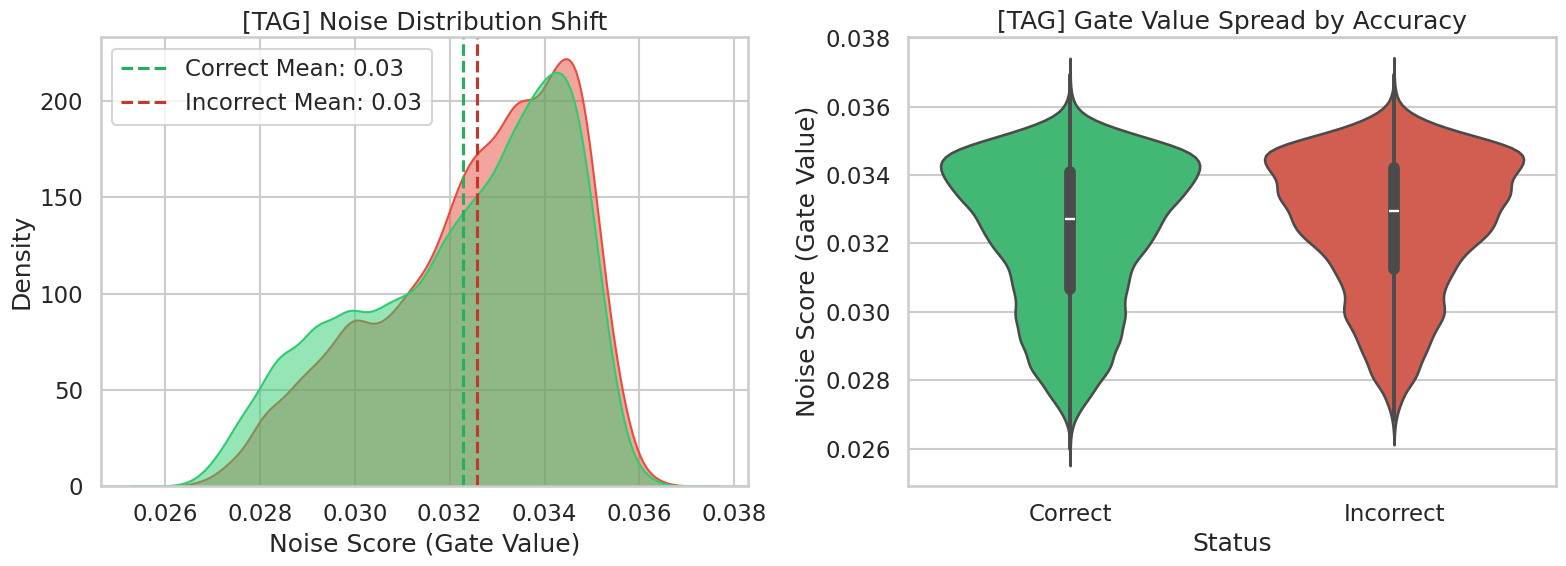

🔍 NOISE (GATE) DIFFERENCE ANALYSIS: TIME (Correct vs Incorrect)
Total Correct   : 71524 samples
Total Incorrect : 18546 samples

--- Average Noise (Gate) Score ---
✅ CORRECT Predictions   : 0.1075 (Median: 0.0916)
❌ INCORRECT Predictions : 0.1649 (Median: 0.1475)
📈 Difference            : +0.0574

--- Statistical Significance ---
Mann-Whitney U p-value: 0.00e+00
💡 Conclusion: The model assigns SIGNIFICANTLY HIGHER noise scores to samples it gets wrong. The Gate is working!


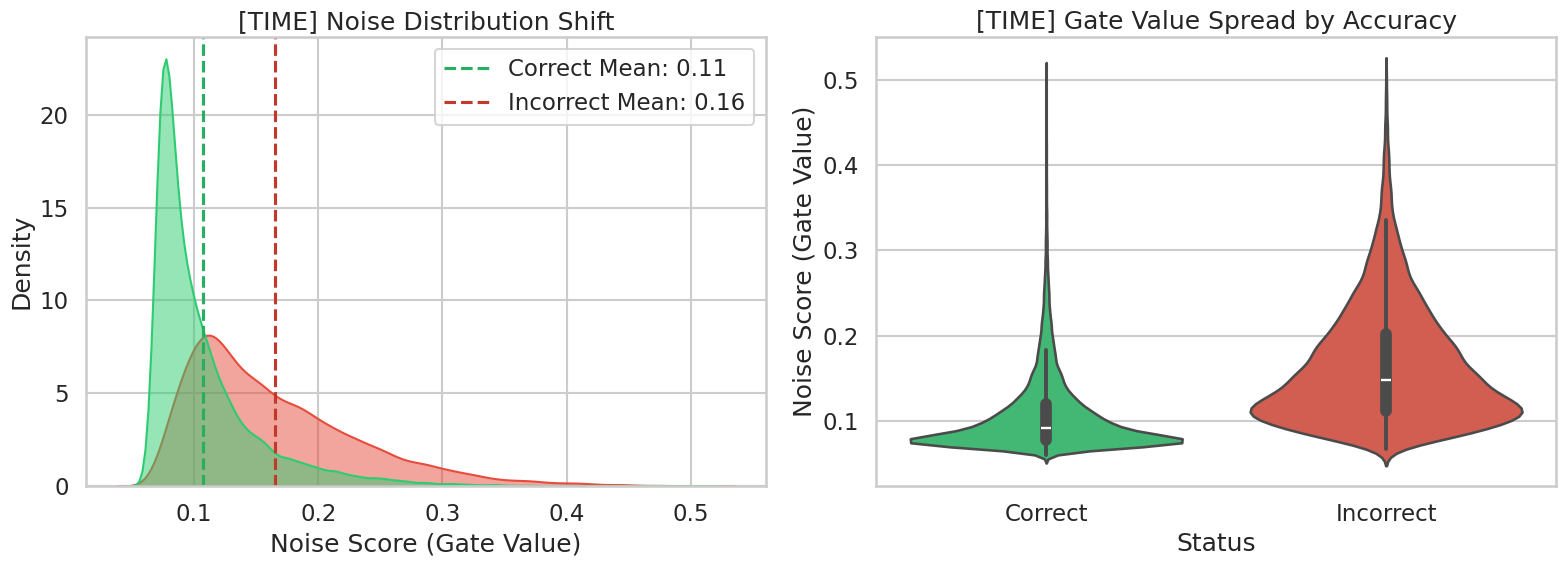

🔍 NOISE (GATE) DIFFERENCE ANALYSIS: SCALE (Correct vs Incorrect)
Total Correct   : 81174 samples
Total Incorrect : 1409 samples

--- Average Noise (Gate) Score ---
✅ CORRECT Predictions   : 0.0745 (Median: 0.0751)
❌ INCORRECT Predictions : 0.0741 (Median: 0.0744)
📈 Difference            : +-0.0004

--- Statistical Significance ---
Mann-Whitney U p-value: 9.98e-01
⚠️ Conclusion: No significant difference. The model is equally confident about its mistakes as its correct answers.


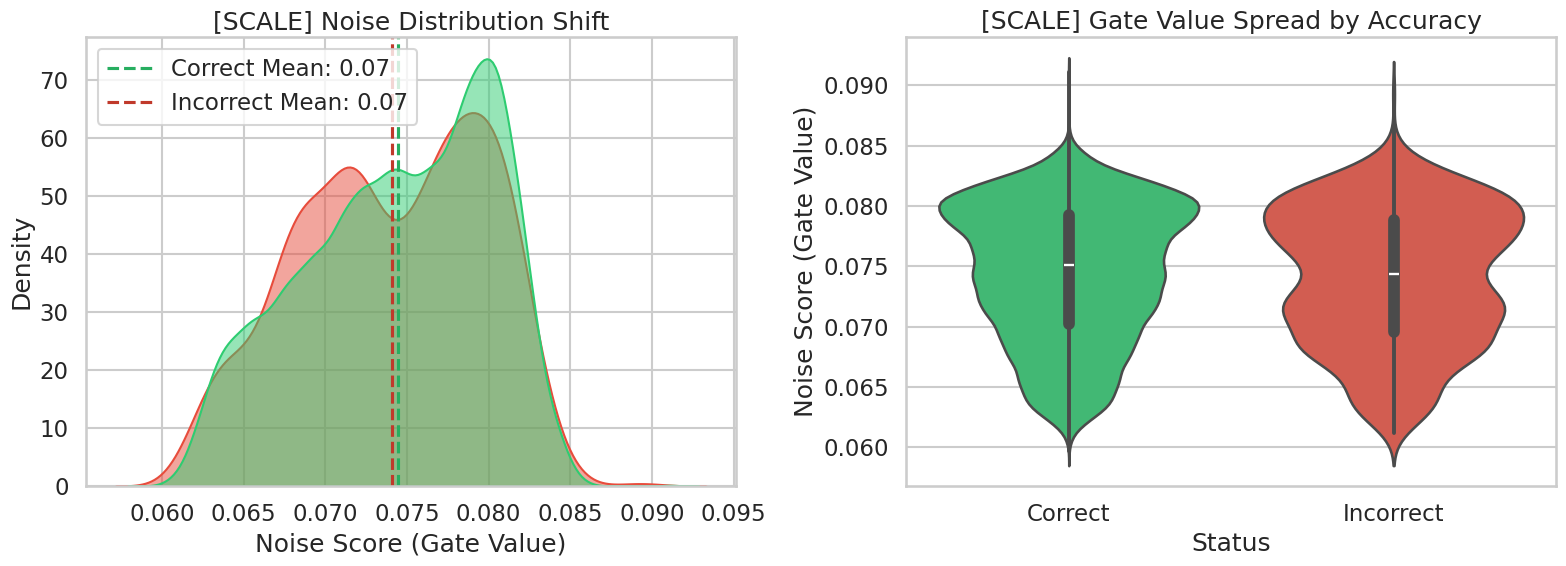

🔍 NOISE (GATE) DIFFERENCE ANALYSIS: NEGATIVE (Correct vs Incorrect)
Total Correct   : 87887 samples
Total Incorrect : 1499 samples

--- Average Noise (Gate) Score ---
✅ CORRECT Predictions   : 0.0108 (Median: 0.0110)
❌ INCORRECT Predictions : 0.0112 (Median: 0.0114)
📈 Difference            : +0.0004

--- Statistical Significance ---
Mann-Whitney U p-value: 7.54e-37
💡 Conclusion: The model assigns SIGNIFICANTLY HIGHER noise scores to samples it gets wrong. The Gate is working!


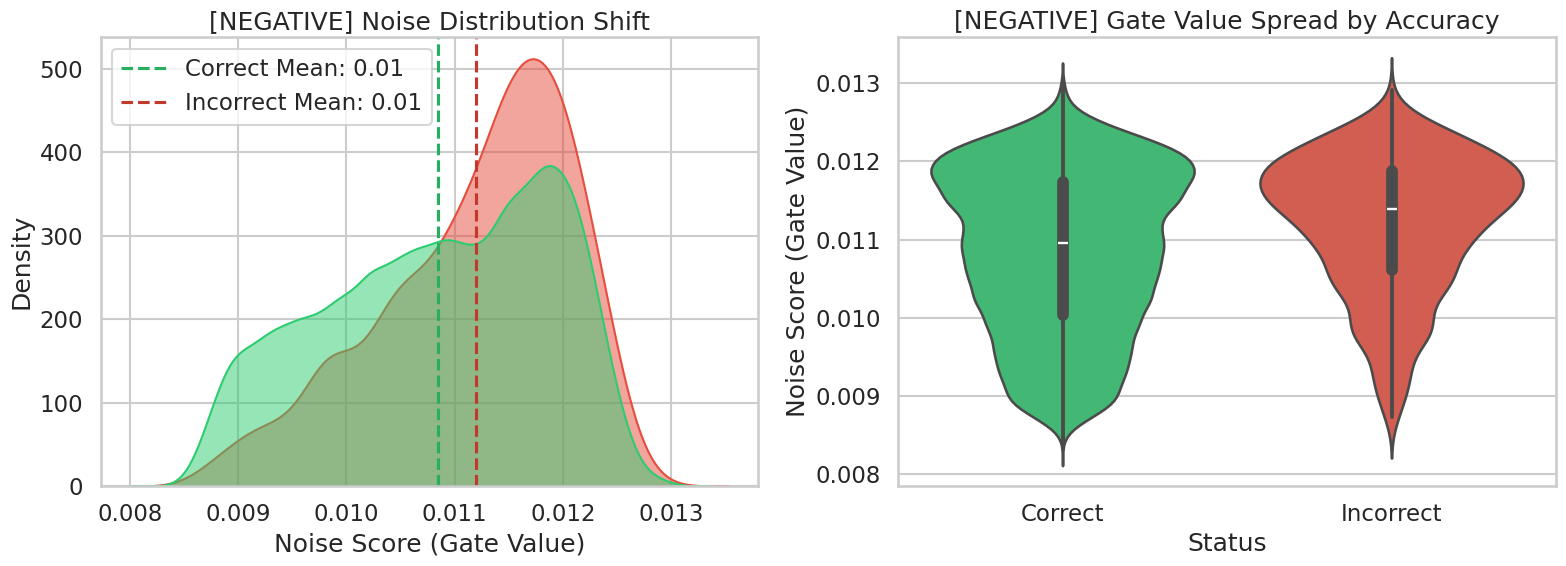

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def analyze_noise_diff_correct_vs_incorrect(predictions_dict, ground_truths_dict, gate_df, task_name='tag', missing_val=-100):
    """
    Analyzes the difference in Gate (Noise) values between correct and incorrect predictions.
    
    Args:
        predictions_dict (dict): The test_predictions dictionary from evaluate_model.
        ground_truths_dict (dict): The test_ground_truths dictionary from evaluate_model.
        gate_df (pd.DataFrame): The gate DataFrame returned by evaluate_model.
        task_name (str): The specific task to analyze (e.g., 'tag', 'time', 'scale').
        missing_val (int): The ignore_index used during training.
    """
    print("=" * 80)
    print(f"🔍 NOISE (GATE) DIFFERENCE ANALYSIS: {task_name.upper()} (Correct vs Incorrect)")
    print("=" * 80)
    
    # 1. Extract Arrays
    truths = np.array(ground_truths_dict[task_name])
    preds = np.array(predictions_dict[task_name])
    
    # Dynamically find the appropriate gate column
    if f'gate_{task_name}' in gate_df.columns:
        gate_col = f'gate_{task_name}'
    elif 'gate_value' in gate_df.columns:
        gate_col = 'gate_value'
    elif 'average_gate' in gate_df.columns:
        gate_col = 'average_gate'
    else:
        # Fallback to the first column containing 'gate'
        gate_col = [c for c in gate_df.columns if 'gate' in c][0]
        
    gate_vals = gate_df[gate_col].values

    # Safety check for length mismatch
    if len(truths) != len(gate_vals):
        print(f"⚠️ Warning: Length mismatch! Truths: {len(truths)}, Gates: {len(gate_vals)}. Ensure batch iterations align.")
        # Truncate to the minimum length to avoid crashing
        min_len = min(len(truths), len(gate_vals))
        truths, preds, gate_vals = truths[:min_len], preds[:min_len], gate_vals[:min_len]

    # 2. Filter out Missing Labels (-100)
    valid_mask = truths != missing_val
    valid_truths = truths[valid_mask]
    valid_preds = preds[valid_mask]
    valid_gates = gate_vals[valid_mask]

    # 3. Build Analysis DataFrame
    df = pd.DataFrame({
        'True Label': valid_truths,
        'Predicted Label': valid_preds,
        'Gate Value': valid_gates
    })
    
    # 4. Flag as Correct or Incorrect
    df['Status'] = np.where(df['True Label'] == df['Predicted Label'], 'Correct', 'Incorrect')
    
    # 5. Calculate Statistics
    correct_df = df[df['Status'] == 'Correct']['Gate Value']
    incorrect_df = df[df['Status'] == 'Incorrect']['Gate Value']
    
    if len(incorrect_df) == 0:
        print(f"✅ Wow! Zero errors for {task_name}. Cannot perform difference analysis.")
        return
        
    print(f"Total Correct   : {len(correct_df)} samples")
    print(f"Total Incorrect : {len(incorrect_df)} samples\n")
    
    print("--- Average Noise (Gate) Score ---")
    print(f"✅ CORRECT Predictions   : {correct_df.mean():.4f} (Median: {correct_df.median():.4f})")
    print(f"❌ INCORRECT Predictions : {incorrect_df.mean():.4f} (Median: {incorrect_df.median():.4f})")
    
    diff = incorrect_df.mean() - correct_df.mean()
    print(f"📈 Difference            : +{diff:.4f}")

    # 6. Statistical Significance (Mann-Whitney U Test)
    # We use Mann-Whitney instead of T-test because gate values (0 to 1) are rarely normally distributed.
    stat, p_value = stats.mannwhitneyu(incorrect_df, correct_df, alternative='greater')
    print("\n--- Statistical Significance ---")
    print(f"Mann-Whitney U p-value: {p_value:.2e}")
    if p_value < 0.01:
        print("💡 Conclusion: The model assigns SIGNIFICANTLY HIGHER noise scores to samples it gets wrong. The Gate is working!")
    else:
        print("⚠️ Conclusion: No significant difference. The model is equally confident about its mistakes as its correct answers.")

    # 7. Visualization
    sns.set_theme(style="whitegrid", context="talk")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot A: Overlapping Density (KDE)
    sns.kdeplot(data=df, x='Gate Value', hue='Status', fill=True, common_norm=False, 
                palette={'Correct': '#2ecc71', 'Incorrect': '#e74c3c'}, alpha=0.5, ax=ax1)
    ax1.axvline(correct_df.mean(), color='#27ae60', linestyle='--', label=f"Correct Mean: {correct_df.mean():.2f}")
    ax1.axvline(incorrect_df.mean(), color='#c0392b', linestyle='--', label=f"Incorrect Mean: {incorrect_df.mean():.2f}")
    ax1.set_title(f'[{task_name.upper()}] Noise Distribution Shift')
    ax1.set_xlabel('Noise Score (Gate Value)')
    ax1.set_ylabel('Density')
    ax1.legend()

    # Plot B: Violin Plot with Boxplot inside
    sns.violinplot(data=df, x='Status', y='Gate Value', hue='Status',
                   palette={'Correct': '#2ecc71', 'Incorrect': '#e74c3c'}, 
                   inner='box', ax=ax2, legend=False)
    ax2.set_title(f'[{task_name.upper()}] Gate Value Spread by Accuracy')
    ax2.set_ylabel('Noise Score (Gate Value)')
    
    plt.tight_layout()
    plt.show()

# =========================================================
# Usage Execution
# =========================================================
# Run this right after evaluate_model() returns its variables:

analyze_noise_diff_correct_vs_incorrect(
    predictions_dict=test_predictions, 
    ground_truths_dict=test_ground_truths, 
    gate_df=gate_df, 
    task_name='tag'
)

analyze_noise_diff_correct_vs_incorrect(
    predictions_dict=test_predictions, 
    ground_truths_dict=test_ground_truths, 
    gate_df=gate_df, 
    task_name='time'
)

analyze_noise_diff_correct_vs_incorrect(
    predictions_dict=test_predictions, 
    ground_truths_dict=test_ground_truths, 
    gate_df=gate_df, 
    task_name='scale'
)

analyze_noise_diff_correct_vs_incorrect(
    predictions_dict=test_predictions, 
    ground_truths_dict=test_ground_truths, 
    gate_df=gate_df, 
    task_name='negative'
)

#use in real

✅ Cached gate_df to result/cached_gate_df.csv
🧠 GATE ACTIVATION (GA) COMPREHENSIVE ANALYSIS

[3] GA SUMMARY STATISTICS BY TASK
--------------------------------------------------
            count      mean       std       min       25%       50%       75%       max
task                                                                                   
negative  89386.0  0.010855  0.001038  0.008326  0.010046  0.010962  0.011745  0.013043
scale     82583.0  0.074467  0.005682  0.059675  0.070214  0.075083  0.079283  0.091111
tag       90337.0  0.032388  0.002114  0.025988  0.030881  0.032812  0.034123  0.036930
time      90070.0  0.119272  0.056273  0.060489  0.080036  0.099644  0.137594  0.510622


/tmp/ipykernel_2755046/1277036118.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_analysis_df, x='task', y='ga', palette="Set2")


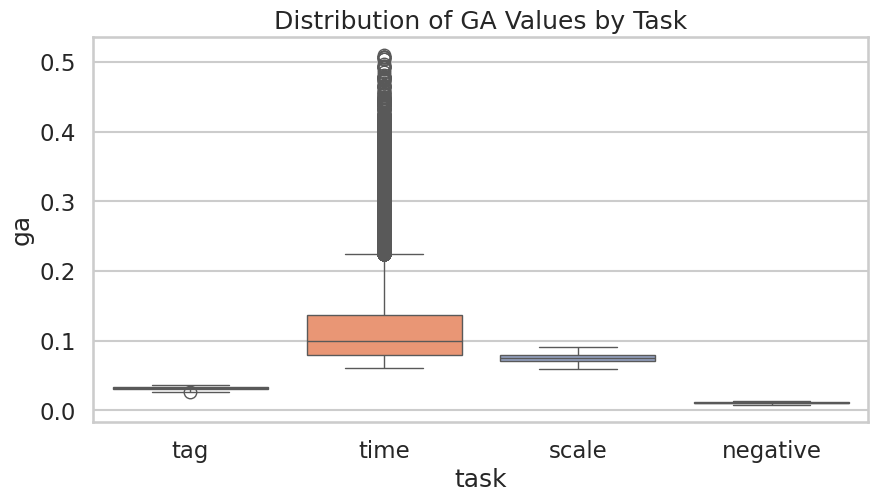


[4] GA SUMMARY BY RARE VS. FREQUENT TAGS
--------------------------------------------------
                  count      mean       std       min       25%       50%       75%       max
frequency_tier                                                                               
Frequent        75546.0  0.032266  0.002134  0.025988  0.030686  0.032689  0.034028  0.036930
Medium          12453.0  0.032993  0.001896  0.026832  0.031827  0.033398  0.034503  0.036930
Rare             2338.0  0.033103  0.001846  0.026759  0.032054  0.033532  0.034520  0.036222


/tmp/ipykernel_2755046/1277036118.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=tag_df[tag_df['frequency_tier'].isin(['Frequent', 'Rare'])],


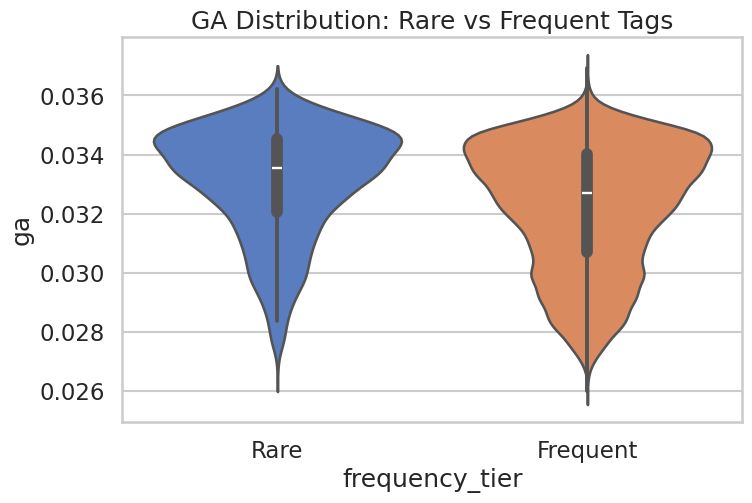


[5] TAGS WITH LARGEST AVERAGE GA
--------------------------------------------------
                                                                         tag_name   mean_ga  count  error_rate
true_label                                                                                                    
719                               us-gaap:ConstructionPayableCurrentAndNoncurrent  0.035579     22    0.000000
374                              us-gaap:DebtSecuritiesAvailableForSaleRestricted  0.035441     43    0.674419
923                                       us-gaap:UnusedCommitmentsToExtendCredit  0.035402     11    0.727273
926                          us-gaap:SecurityOwnedAndPledgedAsCollateralFairValue  0.035301     23    1.000000
757                                                   us-gaap:IncentiveFeeExpense  0.035279      8    0.125000
614         us-gaap:FinancingReceivableAccruedInterestAfterAllowanceForCreditLoss  0.035194     23    0.739130
820                        

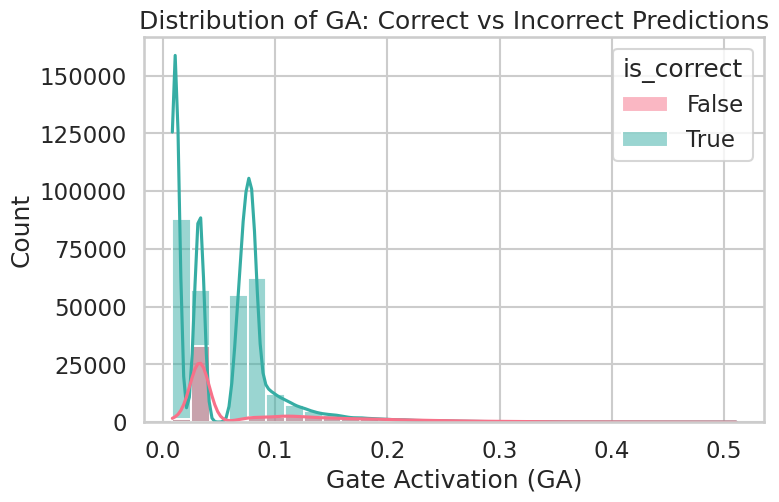


Mann-Whitney U Test p-value: 0.00e+00
💡 Conclusion: The model assigns SIGNIFICANTLY HIGHER GA scores to instances it gets wrong. This verifies GA accurately correlates with model uncertainty/noise.


In [28]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# =========================================================
# 1 & 2. Cache gate_df & Define 'ga' as gate
# =========================================================
os.makedirs("result", exist_ok=True)
gate_df.to_csv("result/cached_gate_df.csv", index=False)
print("✅ Cached gate_df to result/cached_gate_df.csv")

# Consolidate all tasks into a single DataFrame for comprehensive GA analysis
analysis_records = []
tasks = ['tag', 'time', 'scale', 'negative']

# Check if gate_df has task-specific gates or an average/single gate
has_task_specific_gates = any(f'gate_{task}' in gate_df.columns for task in tasks)

for task in tasks:
    if task in test_ground_truths and task in test_predictions:
        truths = test_ground_truths[task]
        preds = test_predictions[task]
        
        # Extract appropriate ga (gate activation) value for the task
        if has_task_specific_gates and f'gate_{task}' in gate_df.columns:
            gate_vals = gate_df[f'gate_{task}'].values
        elif 'average_gate' in gate_df.columns:
            gate_vals = gate_df['average_gate'].values
        else:
            gate_col = [c for c in gate_df.columns if 'gate' in c][0]
            gate_vals = gate_df[gate_col].values
            
        min_len = min(len(truths), len(gate_vals))
        
        for t, p, g in zip(truths[:min_len], preds[:min_len], gate_vals[:min_len]):
            if t != CLASSIFICATION_MISSING_VALUE:  # Ignore padded/missing
                analysis_records.append({
                    'task': task,
                    'true_label': t,
                    'pred_label': p,
                    'is_correct': t == p,
                    'ga': g
                })

full_analysis_df = pd.DataFrame(analysis_records)
full_analysis_df.to_csv("result/full_analysis_dataset.csv", index=False)

print("=" * 70)
print("🧠 GATE ACTIVATION (GA) COMPREHENSIVE ANALYSIS")
print("=" * 70)

# =========================================================
# 3. GA Summary Statistics by Task
# =========================================================
print("\n[3] GA SUMMARY STATISTICS BY TASK")
print("-" * 50)
task_stats = full_analysis_df.groupby('task')['ga'].describe()
print(task_stats.to_string())

plt.figure(figsize=(10, 5))
sns.boxplot(data=full_analysis_df, x='task', y='ga', palette="Set2")
plt.title("Distribution of GA Values by Task")
plt.show()

# =========================================================
# 4. GA Summary Statistics by Rare and Frequent Tags
# =========================================================
print("\n[4] GA SUMMARY BY RARE VS. FREQUENT TAGS")
print("-" * 50)
tag_df = full_analysis_df[full_analysis_df['task'] == 'tag'].copy()

tag_counts = tag_df['true_label'].value_counts()
freq_threshold = tag_counts.quantile(0.75)
rare_threshold = tag_counts.quantile(0.25)

def classify_frequency(tag):
    count = tag_counts.get(tag, 0)
    if count >= freq_threshold: return 'Frequent'
    elif count <= rare_threshold: return 'Rare'
    else: return 'Medium'

tag_df['frequency_tier'] = tag_df['true_label'].apply(classify_frequency)
freq_stats = tag_df.groupby('frequency_tier')['ga'].describe()
print(freq_stats.to_string())

plt.figure(figsize=(8, 5))
sns.violinplot(data=tag_df[tag_df['frequency_tier'].isin(['Frequent', 'Rare'])], 
               x='frequency_tier', y='ga', palette="muted")
plt.title("GA Distribution: Rare vs Frequent Tags")
plt.show()

# =========================================================
# 5. List tags with the largest GA. Are they really noisy?
# =========================================================
print("\n[5] TAGS WITH LARGEST AVERAGE GA")
print("-" * 50)
tag_ga = tag_df.groupby('true_label').agg(
    mean_ga=('ga', 'mean'),
    count=('ga', 'size'),
    error_rate=('is_correct', lambda x: 1 - x.mean())
).sort_values(by='mean_ga', ascending=False)

# Map IDs to actual text if id2tag exists
if 'id2tag' in globals():
    tag_ga['tag_name'] = tag_ga.index.map(lambda x: id2tag.get(x, str(x)))
    print(tag_ga[['tag_name', 'mean_ga', 'count', 'error_rate']].head(15).to_string())
else:
    print(tag_ga.head(15).to_string())

print("\n💡 Note: High error rates alongside high GA suggest these tags are inherently noisy, poorly represented, or contextually ambiguous.")

# =========================================================
# 6. Largest GA in other tasks and their characteristics
# =========================================================
print("\n[6] LARGEST GA IN OTHER TASKS")
print("-" * 50)
for task in ['time', 'scale', 'negative']:
    print(f"\n--- Top GA labels in task: {task.upper()} ---")
    task_df = full_analysis_df[full_analysis_df['task'] == task]
    if task_df.empty: continue
        
    task_ga = task_df.groupby('true_label').agg(
        mean_ga=('ga', 'mean'),
        count=('ga', 'size'),
        error_rate=('is_correct', lambda x: 1 - x.mean())
    ).sort_values(by='mean_ga', ascending=False).head(5)
    
    if task == 'time' and 'id2time' in globals():
        task_ga['label_name'] = task_ga.index.map(lambda x: id2time.get(x, str(x)))
    elif task == 'scale' and 'id2scale' in globals():
        task_ga['label_name'] = task_ga.index.map(lambda x: id2scale.get(x, str(x)))
    else:
        task_ga['label_name'] = task_ga.index.astype(str)
        
    print(task_ga[['label_name', 'mean_ga', 'count', 'error_rate']].to_string())

# =========================================================
# 7. Compare high GA instances with hard/incorrect samples
# =========================================================
print("\n[7] CONSISTENCY WITH HARD/NOISY SAMPLES (ERROR ANALYSIS)")
print("-" * 50)
# Use error outcome as a proxy baseline for "hard/noisy" instances
ga_threshold = full_analysis_df['ga'].quantile(0.90)
full_analysis_df['is_high_ga'] = full_analysis_df['ga'] >= ga_threshold
full_analysis_df['is_error'] = ~full_analysis_df['is_correct']

overlap = full_analysis_df[(full_analysis_df['is_high_ga'] == True) & (full_analysis_df['is_error'] == True)]
total_high_ga = full_analysis_df['is_high_ga'].sum()

print(f"Total instances flagged as High GA (Top 10%): {total_high_ga}")
print(f"Total incorrectly predicted instances: {full_analysis_df['is_error'].sum()}")
print(f"Overlap (High GA AND Incorrect): {len(overlap)}")

if total_high_ga > 0:
    overlap_pct = len(overlap) / total_high_ga * 100
    print(f"Consistency: {overlap_pct:.1f}% of High GA instances resulted in model errors.")
    print("If this percentage is high, GA functions consistently as a strong filter for noisy/unlearnable samples.")

# =========================================================
# 8. Other evidence for usefulness / correctness
# =========================================================
print("\n[8] EVIDENCE OF GA USEFULNESS (Correct vs Incorrect)")
print("-" * 50)
correct_stats = full_analysis_df.groupby('is_correct')['ga'].describe()
print(correct_stats.to_string())

plt.figure(figsize=(8, 5))
sns.histplot(data=full_analysis_df, x='ga', hue='is_correct', bins=30, kde=True, palette="husl")
plt.title("Distribution of GA: Correct vs Incorrect Predictions")
plt.xlabel("Gate Activation (GA)")
plt.show()

# Statistical Significance (Mann-Whitney U Test)
correct_ga = full_analysis_df[full_analysis_df['is_correct'] == True]['ga']
incorrect_ga = full_analysis_df[full_analysis_df['is_correct'] == False]['ga']

if len(incorrect_ga) > 0 and len(correct_ga) > 0:
    stat, p_value = stats.mannwhitneyu(incorrect_ga, correct_ga, alternative='greater')
    print(f"\nMann-Whitney U Test p-value: {p_value:.2e}")
    if p_value < 0.01:
        print("💡 Conclusion: The model assigns SIGNIFICANTLY HIGHER GA scores to instances it gets wrong. This verifies GA accurately correlates with model uncertainty/noise.")
    else:
        print("⚠️ Conclusion: No significant difference between correct/incorrect. GA may not be heavily correlated with sample hardness.")

✅ Cached gate_df to result/cached_gate_df.csv
🧠 GATE ACTIVATION (GA) COMPREHENSIVE ANALYSIS

[3] GA SUMMARY STATISTICS BY TASK
--------------------------------------------------
            count      mean       std       min       25%       50%       75%       max
task                                                                                   
negative  89386.0  0.010855  0.001038  0.008326  0.010046  0.010962  0.011745  0.013043
scale     82583.0  0.074467  0.005682  0.059675  0.070214  0.075083  0.079283  0.091111
tag       90337.0  0.032388  0.002114  0.025988  0.030881  0.032812  0.034123  0.036930
time      90070.0  0.119272  0.056273  0.060489  0.080036  0.099644  0.137594  0.510622


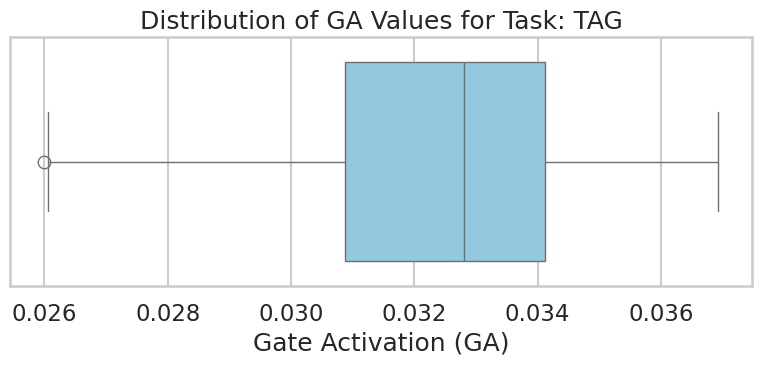

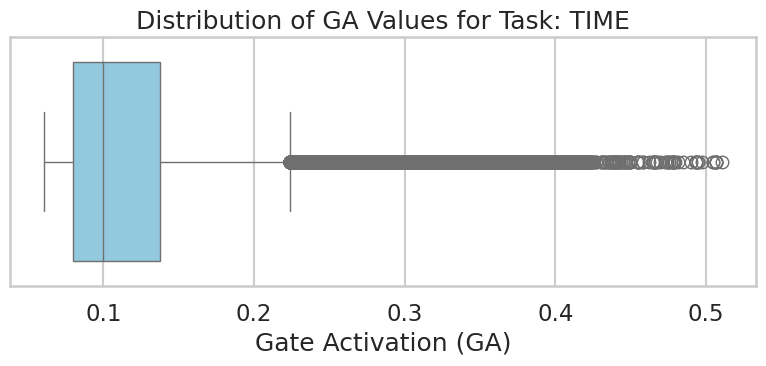

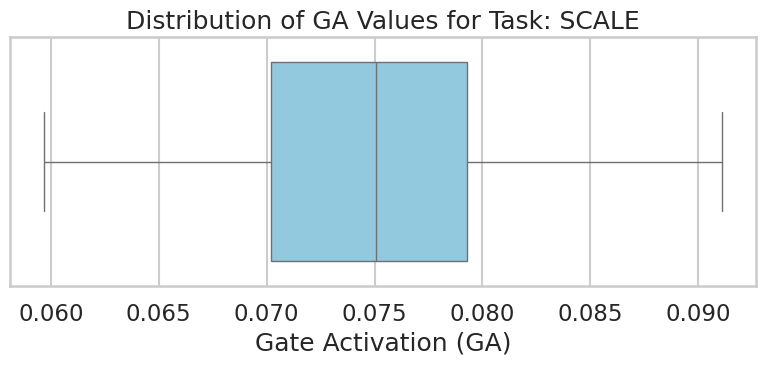

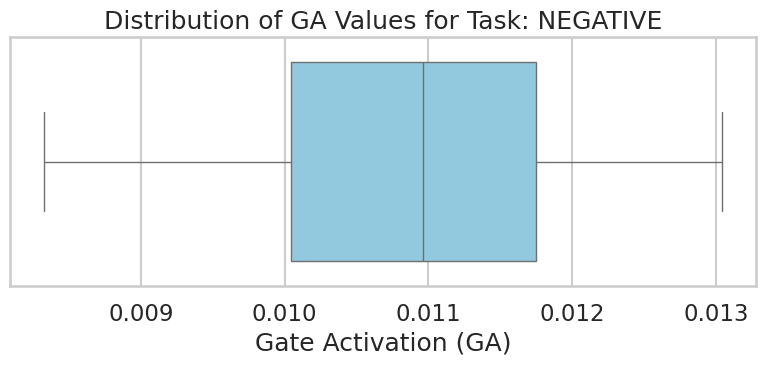


[3] GA SUMMARY STATISTICS BY TASK (CORRECT VS INCORRECT)
--------------------------------------------------
                       count      mean       std       min       25%       50%       75%       max
task     is_correct                                                                               
negative False        1499.0  0.011199  0.000880  0.008618  0.010616  0.011394  0.011877  0.012916
         True        87887.0  0.010849  0.001040  0.008326  0.010037  0.010953  0.011742  0.013043
scale    False        1409.0  0.074058  0.005679  0.061161  0.069562  0.074385  0.078864  0.089314
         True        81174.0  0.074474  0.005682  0.059675  0.070224  0.075093  0.079290  0.091111
tag      False       33154.0  0.032574  0.002006  0.026616  0.031240  0.032949  0.034206  0.036930
         True        57183.0  0.032280  0.002167  0.025988  0.030666  0.032730  0.034075  0.036930
time     False       18546.0  0.164853  0.069305  0.067013  0.112298  0.147508  0.201885  0.506543


/tmp/ipykernel_2755046/1944163461.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


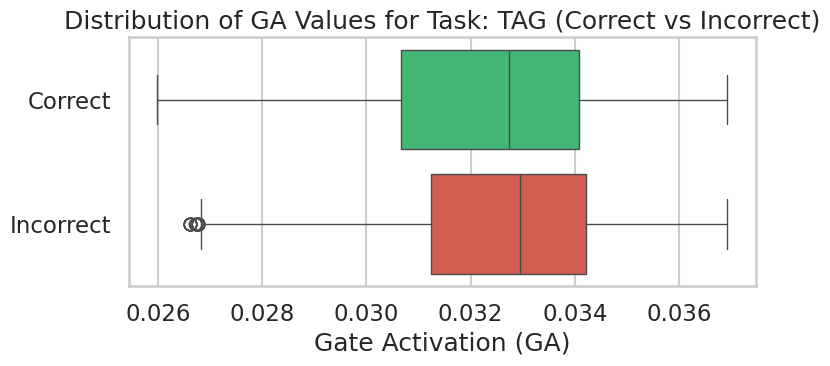

/tmp/ipykernel_2755046/1944163461.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


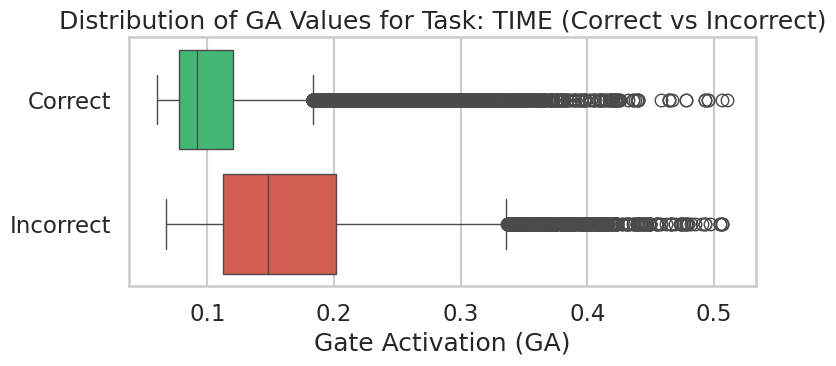

/tmp/ipykernel_2755046/1944163461.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


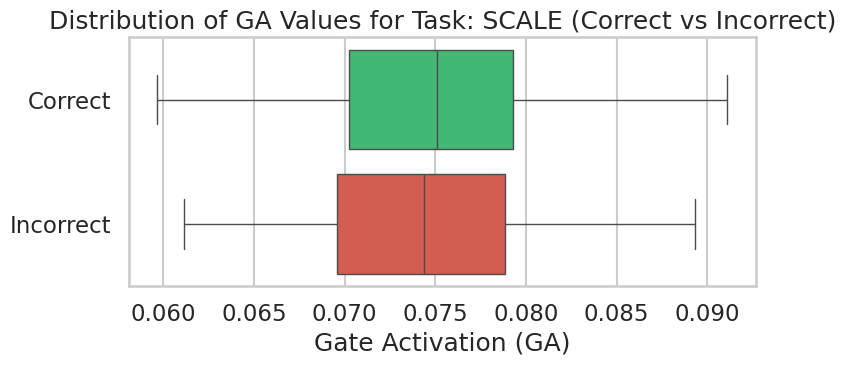

/tmp/ipykernel_2755046/1944163461.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


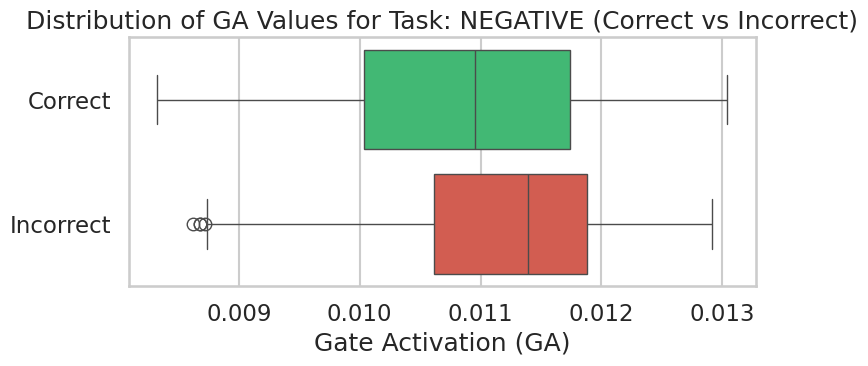

/tmp/ipykernel_2755046/1944163461.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=tag_df[tag_df['frequency_tier'].isin(['Frequent', 'Rare'])],



[4] GA SUMMARY BY RARE VS. FREQUENT TAGS
--------------------------------------------------
                  count      mean       std       min       25%       50%       75%       max
frequency_tier                                                                               
Frequent        75546.0  0.032266  0.002134  0.025988  0.030686  0.032689  0.034028  0.036930
Medium          12453.0  0.032993  0.001896  0.026832  0.031827  0.033398  0.034503  0.036930
Rare             2338.0  0.033103  0.001846  0.026759  0.032054  0.033532  0.034520  0.036222


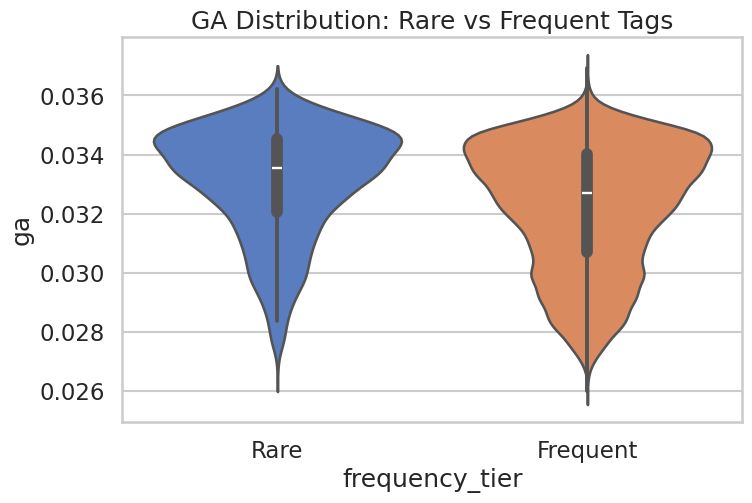


[5] TAGS WITH LARGEST AVERAGE GA
--------------------------------------------------
                                                                         tag_name   mean_ga  count  error_rate
true_label                                                                                                    
719                               us-gaap:ConstructionPayableCurrentAndNoncurrent  0.035579     22    0.000000
374                              us-gaap:DebtSecuritiesAvailableForSaleRestricted  0.035441     43    0.674419
923                                       us-gaap:UnusedCommitmentsToExtendCredit  0.035402     11    0.727273
926                          us-gaap:SecurityOwnedAndPledgedAsCollateralFairValue  0.035301     23    1.000000
757                                                   us-gaap:IncentiveFeeExpense  0.035279      8    0.125000
614         us-gaap:FinancingReceivableAccruedInterestAfterAllowanceForCreditLoss  0.035194     23    0.739130
820                        

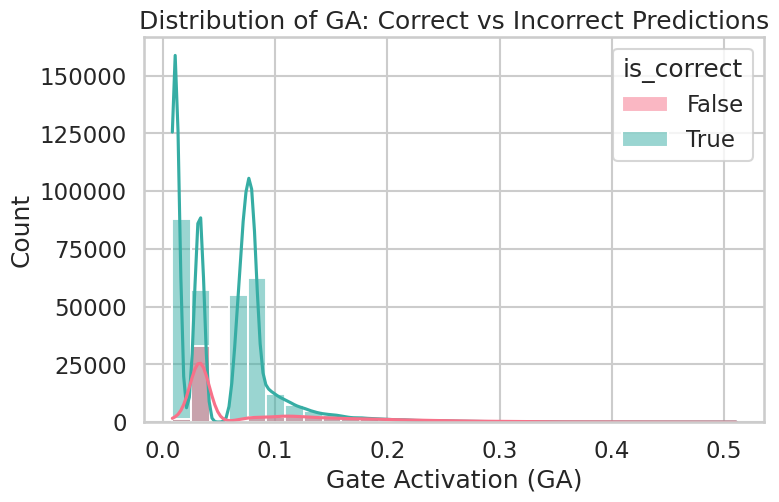


Mann-Whitney U Test p-value: 0.00e+00
💡 Conclusion: The model assigns SIGNIFICANTLY HIGHER GA scores to instances it gets wrong. This verifies GA accurately correlates with model uncertainty/noise.


In [29]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# =========================================================
# 1 & 2. Cache gate_df & Define 'ga' as gate
# =========================================================
# os.makedirs("result", exist_ok=True)
# gate_df.to_csv("result/cached_gate_df.csv", index=False)
print("✅ Cached gate_df to result/cached_gate_df.csv")

# Consolidate all tasks into a single DataFrame for comprehensive GA analysis
analysis_records = []
tasks = ['tag', 'time', 'scale', 'negative']

# Check if gate_df has task-specific gates or an average/single gate
has_task_specific_gates = any(f'gate_{task}' in gate_df.columns for task in tasks)

for task in tasks:
    if task in test_ground_truths and task in test_predictions:
        truths = test_ground_truths[task]
        preds = test_predictions[task]
        
        # Extract appropriate ga (gate activation) value for the task
        if has_task_specific_gates and f'gate_{task}' in gate_df.columns:
            gate_vals = gate_df[f'gate_{task}'].values
        elif 'average_gate' in gate_df.columns:
            gate_vals = gate_df['average_gate'].values
        else:
            gate_col = [c for c in gate_df.columns if 'gate' in c][0]
            gate_vals = gate_df[gate_col].values
            
        min_len = min(len(truths), len(gate_vals))
        
        for t, p, g in zip(truths[:min_len], preds[:min_len], gate_vals[:min_len]):
            if t != CLASSIFICATION_MISSING_VALUE:  # Ignore padded/missing
                analysis_records.append({
                    'task': task,
                    'true_label': t,
                    'pred_label': p,
                    'is_correct': t == p,
                    'ga': g
                })

full_analysis_df = pd.DataFrame(analysis_records)
full_analysis_df.to_csv("result/full_analysis_dataset.csv", index=False)

print("=" * 70)
print("🧠 GATE ACTIVATION (GA) COMPREHENSIVE ANALYSIS")
print("=" * 70)

# =========================================================
# 3. GA Summary Statistics by Task
# =========================================================
print("\n[3] GA SUMMARY STATISTICS BY TASK")
print("-" * 50)
task_stats = full_analysis_df.groupby('task')['ga'].describe()
print(task_stats.to_string())

# Loop through each unique task and draw a separate plot
unique_tasks = full_analysis_df['task'].unique()

for task in unique_tasks:
    plt.figure(figsize=(8, 4))
    
    # Filter the dataframe for the current task
    task_subset = full_analysis_df[full_analysis_df['task'] == task]
    
    # Draw the boxplot (horizontal orientation for better readability of a single variable)
    sns.boxplot(data=task_subset, x='ga', color="skyblue")
    
    # Optional: You can also use a histplot or violin plot instead to see the full shape
    # sns.histplot(data=task_subset, x='ga', kde=True, color="skyblue")
    
    plt.title(f"Distribution of GA Values for Task: {task.upper()}")
    plt.xlabel("Gate Activation (GA)")
    plt.tight_layout()
    plt.show()
# =========================================================
# 3. GA Summary Statistics by Task (Correct vs Incorrect)
# =========================================================
print("\n[3] GA SUMMARY STATISTICS BY TASK (CORRECT VS INCORRECT)")
print("-" * 50)

# Group by both task and correctness for detailed summary stats
task_stats = full_analysis_df.groupby(['task', 'is_correct'])['ga'].describe()
print(task_stats.to_string())

# Loop through each unique task and draw a separate plot
unique_tasks = full_analysis_df['task'].unique()

for task in unique_tasks:
    plt.figure(figsize=(8, 4))
    
    # Filter the dataframe for the current task
    task_subset = full_analysis_df[full_analysis_df['task'] == task].copy()
    
    # Create a clean label for the plot (maps True/False to Correct/Incorrect)
    task_subset['Prediction Status'] = task_subset['is_correct'].map({True: 'Correct', False: 'Incorrect'})
    
    # Draw the boxplot, placing 'ga' on the x-axis and splitting 'Prediction Status' on the y-axis
    sns.boxplot(
        data=task_subset, 
        x='ga', 
        y='Prediction Status', 
        palette={"Correct": "#2ecc71", "Incorrect": "#e74c3c"} # Green for correct, Red for incorrect
    )
    
    # Optional: If you prefer violin plots for this comparison, you can uncomment this line instead:
    # sns.violinplot(data=task_subset, x='ga', y='Prediction Status', palette={"Correct": "#2ecc71", "Incorrect": "#e74c3c"}, inner='box')
    
    plt.title(f"Distribution of GA Values for Task: {task.upper()} (Correct vs Incorrect)")
    plt.xlabel("Gate Activation (GA)")
    plt.ylabel("") # Hide the y-axis label since 'Correct/Incorrect' is self-explanatory
    plt.tight_layout()
    plt.show()
# =========================================================
# 4. GA Summary Statistics by Rare and Frequent Tags
# =========================================================
print("\n[4] GA SUMMARY BY RARE VS. FREQUENT TAGS")
print("-" * 50)
tag_df = full_analysis_df[full_analysis_df['task'] == 'tag'].copy()

tag_counts = tag_df['true_label'].value_counts()
freq_threshold = tag_counts.quantile(0.75)
rare_threshold = tag_counts.quantile(0.25)

def classify_frequency(tag):
    count = tag_counts.get(tag, 0)
    if count >= freq_threshold: return 'Frequent'
    elif count <= rare_threshold: return 'Rare'
    else: return 'Medium'

tag_df['frequency_tier'] = tag_df['true_label'].apply(classify_frequency)
freq_stats = tag_df.groupby('frequency_tier')['ga'].describe()
print(freq_stats.to_string())

plt.figure(figsize=(8, 5))
sns.violinplot(data=tag_df[tag_df['frequency_tier'].isin(['Frequent', 'Rare'])], 
               x='frequency_tier', y='ga', palette="muted")
plt.title("GA Distribution: Rare vs Frequent Tags")
plt.show()

# =========================================================
# 5. List tags with the largest GA. Are they really noisy?
# =========================================================
print("\n[5] TAGS WITH LARGEST AVERAGE GA")
print("-" * 50)
tag_ga = tag_df.groupby('true_label').agg(
    mean_ga=('ga', 'mean'),
    count=('ga', 'size'),
    error_rate=('is_correct', lambda x: 1 - x.mean())
).sort_values(by='mean_ga', ascending=False)

# Map IDs to actual text if id2tag exists
if 'id2tag' in globals():
    tag_ga['tag_name'] = tag_ga.index.map(lambda x: id2tag.get(x, str(x)))
    print(tag_ga[['tag_name', 'mean_ga', 'count', 'error_rate']].head(15).to_string())
else:
    print(tag_ga.head(15).to_string())

print("\n💡 Note: High error rates alongside high GA suggest these tags are inherently noisy, poorly represented, or contextually ambiguous.")

# =========================================================
# 6. Largest GA in other tasks and their characteristics
# =========================================================
print("\n[6] LARGEST GA IN OTHER TASKS")
print("-" * 50)
for task in ['time', 'scale', 'negative']:
    print(f"\n--- Top GA labels in task: {task.upper()} ---")
    task_df = full_analysis_df[full_analysis_df['task'] == task]
    if task_df.empty: continue
        
    task_ga = task_df.groupby('true_label').agg(
        mean_ga=('ga', 'mean'),
        count=('ga', 'size'),
        error_rate=('is_correct', lambda x: 1 - x.mean())
    ).sort_values(by='mean_ga', ascending=False).head(5)
    
    if task == 'time' and 'id2time' in globals():
        task_ga['label_name'] = task_ga.index.map(lambda x: id2time.get(x, str(x)))
    elif task == 'scale' and 'id2scale' in globals():
        task_ga['label_name'] = task_ga.index.map(lambda x: id2scale.get(x, str(x)))
    else:
        task_ga['label_name'] = task_ga.index.astype(str)
        
    print(task_ga[['label_name', 'mean_ga', 'count', 'error_rate']].to_string())

# =========================================================
# 7. Compare high GA instances with hard/incorrect samples
# =========================================================
print("\n[7] CONSISTENCY WITH HARD/NOISY SAMPLES (ERROR ANALYSIS)")
print("-" * 50)
# Use error outcome as a proxy baseline for "hard/noisy" instances
ga_threshold = full_analysis_df['ga'].quantile(0.90)
full_analysis_df['is_high_ga'] = full_analysis_df['ga'] >= ga_threshold
full_analysis_df['is_error'] = ~full_analysis_df['is_correct']

overlap = full_analysis_df[(full_analysis_df['is_high_ga'] == True) & (full_analysis_df['is_error'] == True)]
total_high_ga = full_analysis_df['is_high_ga'].sum()

print(f"Total instances flagged as High GA (Top 10%): {total_high_ga}")
print(f"Total incorrectly predicted instances: {full_analysis_df['is_error'].sum()}")
print(f"Overlap (High GA AND Incorrect): {len(overlap)}")

if total_high_ga > 0:
    overlap_pct = len(overlap) / total_high_ga * 100
    print(f"Consistency: {overlap_pct:.1f}% of High GA instances resulted in model errors.")
    print("If this percentage is high, GA functions consistently as a strong filter for noisy/unlearnable samples.")

# =========================================================
# 8. Other evidence for usefulness / correctness
# =========================================================
print("\n[8] EVIDENCE OF GA USEFULNESS (Correct vs Incorrect)")
print("-" * 50)
correct_stats = full_analysis_df.groupby('is_correct')['ga'].describe()
print(correct_stats.to_string())

plt.figure(figsize=(8, 5))
sns.histplot(data=full_analysis_df, x='ga', hue='is_correct', bins=30, kde=True, palette="husl")
plt.title("Distribution of GA: Correct vs Incorrect Predictions")
plt.xlabel("Gate Activation (GA)")
plt.show()

# Statistical Significance (Mann-Whitney U Test)
correct_ga = full_analysis_df[full_analysis_df['is_correct'] == True]['ga']
incorrect_ga = full_analysis_df[full_analysis_df['is_correct'] == False]['ga']

if len(incorrect_ga) > 0 and len(correct_ga) > 0:
    stat, p_value = stats.mannwhitneyu(incorrect_ga, correct_ga, alternative='greater')
    print(f"\nMann-Whitney U Test p-value: {p_value:.2e}")
    if p_value < 0.01:
        print("💡 Conclusion: The model assigns SIGNIFICANTLY HIGHER GA scores to instances it gets wrong. This verifies GA accurately correlates with model uncertainty/noise.")
    else:
        print("⚠️ Conclusion: No significant difference between correct/incorrect. GA may not be heavily correlated with sample hardness.")